## Laboratorium 11

slajd 112 wyswietlic - ile razy algorytm sie pomylił i wybrał złego dostawcę

zadania ze slajdu 104

w 3 punkcie zmiana u dostawców (np jeden przestaje być najlepszym)

In [276]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
import random

random.seed(42)

1. Reproduce example from the lecture (electronic system production)

In [277]:
class Batch:
    quality = 0.5
    alpha = 1
    beta = 1

    def __init__(self, quality):
        self.quality = quality

    def sample_distribution(self):
        return np.random.beta(self.alpha, self.beta)

    def get_element(self):
        good = np.random.rand() < self.quality
        self.alpha = self.alpha + int(good)
        self.beta = self.beta + 1 - int(good)
        return good


class Factory:
    batches = []
    systems = 0
    good = 0

    def set_batches(self, qualities):
        self.batches = [Batch(quality) for quality in qualities]
        self.systems = 0
        self.good = 0

    def get_element(self):
        samples = [batch.sample_distribution() for batch in self.batches]
        choice = np.argmax(samples)
        result = self.batches[choice].get_element()
        self.systems = self.systems + 1
        self.good = self.good + int(result)

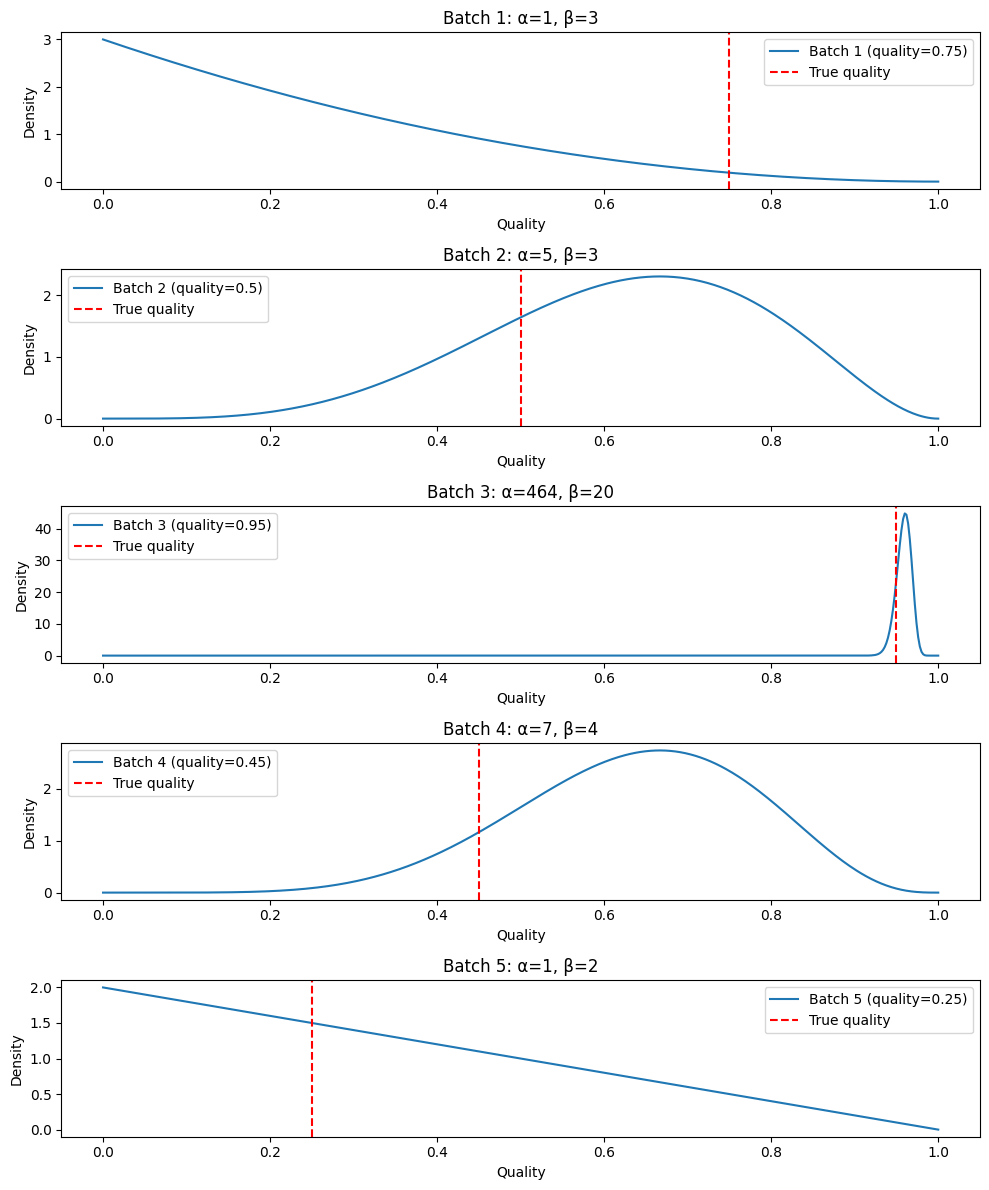

In [278]:
BATCHES_NUM = 5
qualities = [0.75, 0.5, 0.95, 0.45, 0.25]

STEPS = 500

factory = Factory()
factory.set_batches(qualities)
res = {}

for step in range(STEPS):
    factory.get_element()
    res[step] = [(b.alpha, b.beta, b.quality) for b in factory.batches]

x = np.linspace(0,1,STEPS)
fig, axes = plt.subplots(BATCHES_NUM, 1, figsize=(10, 12))

for i in range(BATCHES_NUM):
    alpha_final, beta_final, quality = res[STEPS-1][i]
    y = beta.pdf(x, alpha_final, beta_final)
    axes[i].plot(x, y, label=f'Batch {i+1} (quality={quality})')
    axes[i].axvline(quality, color='r', linestyle='--', label='True quality')
    axes[i].set_title(f'Batch {i+1}: α={alpha_final}, β={beta_final}')
    axes[i].legend()
    axes[i].set_xlabel('Quality')
    axes[i].set_ylabel('Density')

plt.tight_layout()
plt.show()

2. Implement last three strategies from slide 105 plus one of your own (other than the two 
remaining in the slide), compare results in a plot.

In [279]:
class Batch:
    quality = 0.5
    alpha = 1
    beta = 1
    def __init__(self, quality):
        self.quality = quality
    
    def sample_distribution(self):
        return np.random.beta(self.alpha, self.beta)
    
    def get_element(self):
        good = np.random.rand() < self.quality
        self.alpha = self.alpha + int(good)
        self.beta = self.beta + 1 - int(good)
        return good
    
class Factory:
    batches = []
    systems = 0
    good = 0

    def reset(self):
        self.systems = 0          
        self.good = 0
    
    def set_batches(self, qualities):
        self.batches = [Batch(quality) for quality in qualities]
        self.n_batches = len(qualities)
        self.systems = 0
        self.good = 0
    
    def lemon_method(self, steps):
        results = []
        batch_success = np.zeros(self.n_batches)
        batch_total = np.zeros(self.n_batches)

        last_batch_idx = 0
        for step in range(steps):
            choice = last_batch_idx
            result = self.batches[choice].get_element()
            batch_success[choice] += int(result)
            batch_total[choice] += 1
            
            self.systems = self.systems + 1
            self.good = self.good + int(result)
            # print(f"Batch chosen: {choice} -> res: {result}")
            # print(f"Batch: {self.batches[choice].alpha} | {self.batches[choice].beta}\n")
            if result == False:
                last_batch_idx = last_batch_idx + 1 if last_batch_idx + 1 < self.n_batches else 0
            results.append(result)
            
        return results.count(True), batch_success, batch_total
    
    def rank_descending_method(self, steps):
        results = []
        batch_success = np.zeros(self.n_batches)
        batch_total = np.zeros(self.n_batches)

        for step in range(steps):
            successes = np.array([b.alpha - 1 for b in self.batches])
            failures = np.array([b.beta  - 1 for b in self.batches])
            total = successes + failures
            # print(f"{successes}, {failures}, {total}")

            mean_success = np.where(total > 0, successes / total, 0.5)

            order = np.argsort(-mean_success)
            choose_list = []
            for i, idx in enumerate(order):
                choose_list += [idx] * (self.n_batches - i)

            # print(choose_list)
            choice = choose_list[step % len(choose_list)]

            result = self.batches[choice].get_element()
            batch_success[choice] += int(result)
            batch_total[choice] += 1
            # print(f"Batch chosen: {choice} -> res: {result}")
            # print(f"Batch: {self.batches[choice].alpha} | {self.batches[choice].beta}\n")

            self.systems = self.systems + 1
            self.good = self.good + int(result)
            
            results.append(result)
        
        # return sum(batch_success) / sum(batch_used)
        return results.count(True), batch_success, batch_total
    
    def ratio_geometric_method(self, steps):
        results = []
        batch_success = np.zeros(self.n_batches)
        batch_total = np.zeros(self.n_batches)

        for step in range(steps):
            successes = np.array([b.alpha - 1 for b in self.batches])
            failures = np.array([b.beta  - 1 for b in self.batches])
            total = successes + failures
            # print(f"{successes}, {failures}, {total}")

            mean_success = np.where(total > 0, successes / total, 0.5)
            order = np.argsort(mean_success)

            sorted_success = mean_success[order]
            ratios = np.zeros(len(order))
            ratios[0] = 1.0                       
            for i in range(1, len(order)):
                if sorted_success[i-1] == 0:
                    ratios[i] = 2.0
                else:
                    ratios[i] = sorted_success[i] / sorted_success[i-1]

            choose_list = []
            base_amount = 1.0
            for i, batch_idx in enumerate(order):
                amount = max(1, round(base_amount))
                choose_list += [batch_idx] * amount
                base_amount *= ratios[i]

            position = self.systems % len(choose_list)
            choice = choose_list[position]

            result = self.batches[choice].get_element()
            batch_success[choice] += int(result)
            batch_total[choice] += 1
            # print(f"Batch chosen: {choice} -> res: {result}")
            # print(f"Batch: {self.batches[choice].alpha} | {self.batches[choice].beta}\n")

            self.systems = self.systems + 1
            self.good = self.good + int(result)
            results.append(result)
        
        return results.count(True), batch_success, batch_total
    
    def softmax_method(self, steps, temp=4.0):
        results = []
        batch_success = np.zeros(self.n_batches)
        batch_total = np.zeros(self.n_batches)

        for step in range(steps):
            successes = np.array([b.alpha - 1 for b in self.batches])
            failures = np.array([b.beta  - 1 for b in self.batches])
            total = successes + failures
            # print(f"{successes}, {failures}, {total}")

            mean_success = np.where(total > 0, successes / total, 0.5)
            
            logits = mean_success / temp
            logits -= np.max(logits)
            exp_logits = np.exp(logits)
            probs = exp_logits / np.sum(exp_logits)

            choice = np.random.choice(self.n_batches, p=probs)
            
            result = self.batches[choice].get_element()
            batch_success[choice] += int(result)
            batch_total[choice] += 1
            # print(f"Batch chosen: {choice} -> res: {result}")
            # print(f"Batch: {self.batches[choice].alpha} | {self.batches[choice].beta}\n")

            self.systems = self.systems + 1
            self.good = self.good + int(result)
            results.append(result)
    
        return results.count(True), batch_success, batch_total
            


In [280]:
# BATCHES_NUM = 5
qualities = [0.65, 0.70, 0.75, 0.8, 0.85]
# qualities = [0.9, 0.6, 0.5, 0.4, 0.3]

STEPS = 100
SIM_NUMS = 1

scores = []

Lemon method:

In [281]:
lemon_scores = []
for _ in range(SIM_NUMS):
    factory = Factory()
    factory.set_batches(qualities)
    results, batch_success, batch_total = factory.lemon_method(STEPS)
    for i, b in enumerate(factory.batches):
        print(f"Batch {i}: Alpha: {b.alpha} | Beta: {b.beta}")
    factory.reset()
    lemon_scores.append(results / STEPS)
    
    if _ < 1:
        print(f"Success rate: {results / STEPS}")
        print(batch_success)
        print(batch_total)

scores.append(np.average(lemon_scores))
print(f"Avg. success rate: {sum(lemon_scores) / SIM_NUMS}")
print("Successful batch use:")
for i in range(len(qualities)):
    print(f"Batch {i} (qual: {qualities[i]}): {batch_success[i]}/{batch_total[i]}")


Batch 0: Alpha: 16 | Beta: 7
Batch 1: Alpha: 10 | Beta: 7
Batch 2: Alpha: 15 | Beta: 7
Batch 3: Alpha: 25 | Beta: 6
Batch 4: Alpha: 11 | Beta: 6
Success rate: 0.72
[15.  9. 14. 24. 10.]
[21. 15. 20. 29. 15.]
Avg. success rate: 0.72
Successful batch use:
Batch 0 (qual: 0.65): 15.0/21.0
Batch 1 (qual: 0.7): 9.0/15.0
Batch 2 (qual: 0.75): 14.0/20.0
Batch 3 (qual: 0.8): 24.0/29.0
Batch 4 (qual: 0.85): 10.0/15.0


Ranking descending method:

In [282]:
rank_scores = []
for _ in range(SIM_NUMS):
    factory = Factory()
    factory.set_batches(qualities)
    results, batch_success, batch_total = factory.rank_descending_method(STEPS)
    for i, b in enumerate(factory.batches):
        print(f"Batch {i}: Alpha: {b.alpha} | Beta: {b.beta}")
    factory.reset() 
    rank_scores.append(results / STEPS)

    if _ < 1:
        print(f"Success rate: {results / STEPS}")
        print(batch_success)
        print(batch_total)

scores.append(np.average(rank_scores))
print(f"Avg. success rate: {sum(rank_scores) / SIM_NUMS}")
print("Successful batch use:")
for i in range(len(qualities)):
    print(f"Batch {i} (qual: {qualities[i]}: {batch_success[i]}/{batch_total[i]}")


Batch 0: Alpha: 9 | Beta: 13
Batch 1: Alpha: 7 | Beta: 5
Batch 2: Alpha: 28 | Beta: 5
Batch 3: Alpha: 12 | Beta: 7
Batch 4: Alpha: 21 | Beta: 3
Success rate: 0.72
[ 8.  6. 27. 11. 20.]
[20. 10. 31. 17. 22.]
Avg. success rate: 0.72
Successful batch use:
Batch 0 (qual: 0.65: 8.0/20.0
Batch 1 (qual: 0.7: 6.0/10.0
Batch 2 (qual: 0.75: 27.0/31.0
Batch 3 (qual: 0.8: 11.0/17.0
Batch 4 (qual: 0.85: 20.0/22.0


C:\Users\jasin\AppData\Local\Temp\ipykernel_22052\2245016649.py:65: RuntimeWarning: invalid value encountered in divide
  mean_success = np.where(total > 0, successes / total, 0.5)


Ratio score method:

In [283]:
ratio_scores = []
for _ in range(SIM_NUMS):
    factory = Factory()
    factory.set_batches(qualities)
    results, batch_success, batch_total = factory.ratio_geometric_method(STEPS)
    for i, b in enumerate(factory.batches):
        print(f"Batch {i}: Alpha: {b.alpha} | Beta: {b.beta}")
    factory.reset() 
    ratio_scores.append(results / STEPS)

    if _ < 1:
        print(f"Success rate: {results / STEPS}")
        print(batch_success)
        print(batch_total)
        
scores.append(np.average(ratio_scores))
print(f"Avg. success rate: {sum(ratio_scores) / SIM_NUMS}")
print("Successful batch use:")
for i in range(len(qualities)):
    print(f"Batch {i} (qual: {qualities[i]}): {batch_success[i]}/{batch_total[i]}")


Batch 0: Alpha: 15 | Beta: 10
Batch 1: Alpha: 13 | Beta: 3
Batch 2: Alpha: 16 | Beta: 5
Batch 3: Alpha: 10 | Beta: 6
Batch 4: Alpha: 26 | Beta: 6
Success rate: 0.75
[14. 12. 15.  9. 25.]
[23. 14. 19. 14. 30.]
Avg. success rate: 0.75
Successful batch use:
Batch 0 (qual: 0.65): 14.0/23.0
Batch 1 (qual: 0.7): 12.0/14.0
Batch 2 (qual: 0.75): 15.0/19.0
Batch 3 (qual: 0.8): 9.0/14.0
Batch 4 (qual: 0.85): 25.0/30.0


C:\Users\jasin\AppData\Local\Temp\ipykernel_22052\2245016649.py:100: RuntimeWarning: invalid value encountered in divide
  mean_success = np.where(total > 0, successes / total, 0.5)


Own method - softmax:

In [284]:
softmax_scores = []
for _ in range(SIM_NUMS):
    factory = Factory()
    factory.set_batches(qualities)
    results, batch_success, batch_total = factory.softmax_method(STEPS)
    for i, b in enumerate(factory.batches):
        print(f"Batch {i}: Alpha: {b.alpha} | Beta: {b.beta}")
    factory.reset() 
    softmax_scores.append(results / STEPS)

    if _ < 1:
        print(f"Success rate: {results / STEPS}")
        print(batch_success)
        print(batch_total)

scores.append(np.average(softmax_scores))
print(f"Avg. success rate: {sum(softmax_scores) / SIM_NUMS}")
print("Successful batch use:")
for i in range(len(qualities)):
    print(f"Batch {i} (qual: {qualities[i]}): {batch_success[i]}/{batch_total[i]}")

Batch 0: Alpha: 10 | Beta: 6
Batch 1: Alpha: 16 | Beta: 6
Batch 2: Alpha: 17 | Beta: 5
Batch 3: Alpha: 25 | Beta: 2
Batch 4: Alpha: 19 | Beta: 4
Success rate: 0.82
[ 9. 15. 16. 24. 18.]
[14. 20. 20. 25. 21.]
Avg. success rate: 0.82
Successful batch use:
Batch 0 (qual: 0.65): 9.0/14.0
Batch 1 (qual: 0.7): 15.0/20.0
Batch 2 (qual: 0.75): 16.0/20.0
Batch 3 (qual: 0.8): 24.0/25.0
Batch 4 (qual: 0.85): 18.0/21.0


C:\Users\jasin\AppData\Local\Temp\ipykernel_22052\2245016649.py:145: RuntimeWarning: invalid value encountered in divide
  mean_success = np.where(total > 0, successes / total, 0.5)


[np.float64(0.72), np.float64(0.72), np.float64(0.75), np.float64(0.82)]


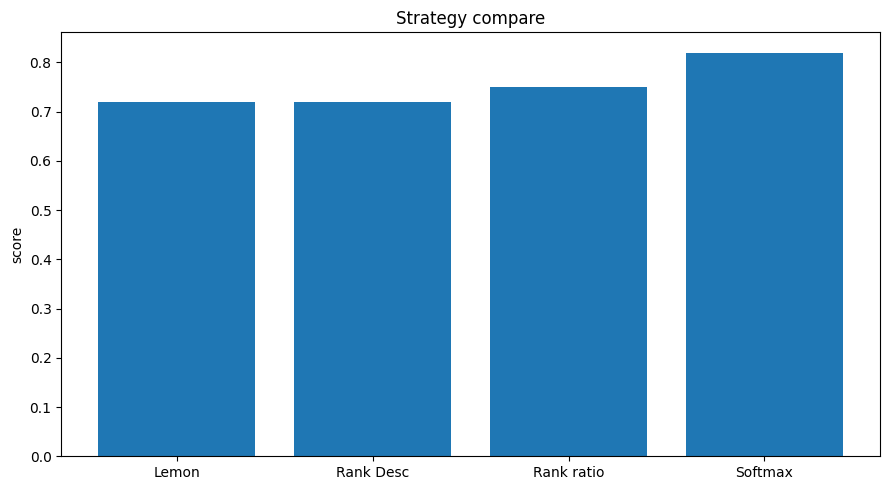

In [285]:
names = ["Lemon", "Rank Desc", "Rank ratio", "Softmax"]
print(scores)
plt.figure(figsize=(9,5))
plt.bar(names, scores)
plt.ylabel("score")
plt.title("Strategy compare")
plt.tight_layout()
plt.show()

3. In real life it is possible that the quality of components from a manufacture changes in time. 
Implement “imperfect memory” in the Bayesian strategy that makes it gradually forget the 
learned parameters of Beta distribution for each batch. Check using an appropriate example.

In [286]:
class BatchWithMemory:
    quality = 0.5
    alpha = 1
    beta = 1
    
    def __init__(self, quality, decay_rate=0.99):
        self.quality = quality
        self.decay_rate = decay_rate
        self.initial_alpha = 1
        self.initial_beta = 1
    
    def sample_distribution(self):
        return np.random.beta(self.alpha, self.beta)
    
    def get_element(self):
        good = np.random.rand() < self.quality
        self.alpha = self.alpha + int(good)
        self.beta = self.beta + 1 - int(good)
        return good
    
    def apply_memory_decay(self):
        self.alpha = self.decay_rate * self.alpha + (1 - self.decay_rate) * self.initial_alpha
        self.beta = self.decay_rate * self.beta + (1 - self.decay_rate) * self.initial_beta
    
    def change_quality(self, new_quality):
        self.quality = new_quality


class FactoryWithMemory:
    batches = []
    systems = 0
    good = 0
    
    def reset(self):
        self.systems = 0          
        self.good = 0
    
    def set_batches(self, qualities, decay_rate=0.9):
        self.batches = [BatchWithMemory(quality, decay_rate) for quality in qualities]
        self.n_batches = len(qualities)
        self.systems = 0
        self.good = 0
    
    def thompson_sampling_method(self, steps, decay_interval=10, quality_changes=None):
        results = []
        batch_success = np.zeros(self.n_batches)
        batch_total = np.zeros(self.n_batches)
        
        history = {i: {'alpha': [], 'beta': [], 'quality': []} for i in range(self.n_batches)}
        
        for step in range(steps):
            if quality_changes and step in quality_changes:
                for batch_idx, new_quality in quality_changes[step].items():
                    self.batches[batch_idx].change_quality(new_quality)
                    print(f"Step {step}: Batch {batch_idx} quality changed to {new_quality}")
            
            samples = [batch.sample_distribution() for batch in self.batches]
            choice = np.argmax(samples)
            
            result = self.batches[choice].get_element()
            batch_success[choice] += int(result)
            batch_total[choice] += 1
            
            for i, b in enumerate(self.batches):
                history[i]['alpha'].append(b.alpha)
                history[i]['beta'].append(b.beta)
                history[i]['quality'].append(b.quality)
            
            if (step + 1) % decay_interval == 0:
                for batch in self.batches:
                    batch.apply_memory_decay()
            
            self.systems += 1
            self.good += int(result)
            results.append(result)
        
        return results, batch_success, batch_total, history

Batch 0: Alpha: 4.305696591897576 | Beta: 3.490217293259296
Batch 1: Alpha: 5.763668163218772 | Beta: 3.482423480474572
Batch 2: Alpha: 6.460819141223294 | Beta: 3.3701862617969174
Batch 3: Alpha: 20.141171571300983 | Beta: 3.401691473722072
Batch 4: Alpha: 41.2147042567066 | Beta: 7.905581997741145
Success rate: 0.792
[ 23.  54.  96.  63. 160.]
[ 36.  73. 123.  78. 190.]
Avg. success rate: 0.792
Successful batch use:
Batch 0 (qual: 0.65): 23.0/36.0
Batch 1 (qual: 0.7): 54.0/73.0
Batch 2 (qual: 0.75): 96.0/123.0
Batch 3 (qual: 0.8): 63.0/78.0
Batch 4 (qual: 0.85): 160.0/190.0
[True, False, False, False, True, True, True, True, True, True, True, False, True, False, False, False, True, True, True, True, True, True, True, True, False, True, True, False, False, True, True, False, True, True, True, True, False, True, True, True, True, True, True, True, True, True, True, True, True, True, False, False, True, True, True, True, True, True, False, True, True, False, False, True, True, True, Tru

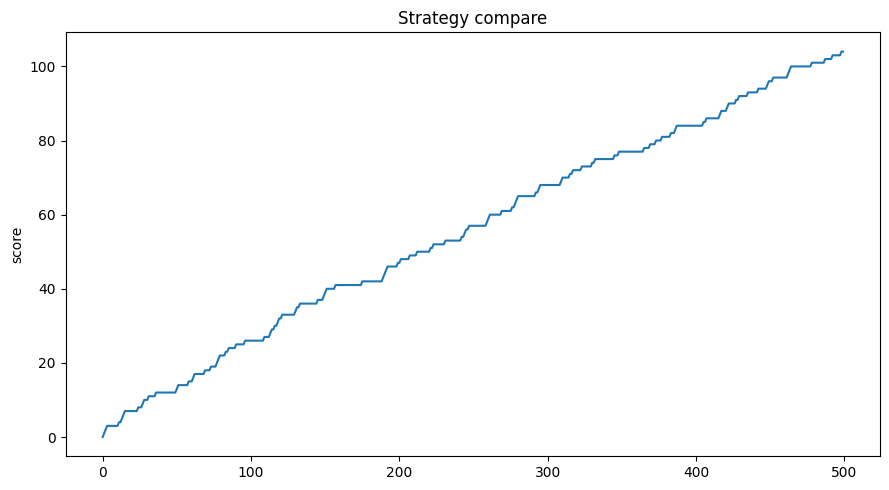

In [287]:
init_qualities = [0.65, 0.7, 0.75, 0.8, 0.85]
thompson_scores = []

STEPS = 500
DECAY_INTERVAL = 10
DECAY_RATE: 0.9

for _ in range(SIM_NUMS):
    factory = FactoryWithMemory()
    factory.set_batches(init_qualities)

    results, batch_success, batch_total, history = factory.thompson_sampling_method(STEPS,
        decay_interval=DECAY_INTERVAL)
    
    for i, b in enumerate(factory.batches):
        print(f"Batch {i}: Alpha: {b.alpha} | Beta: {b.beta}")
    factory.reset() 
    thompson_scores.append(results.count(True) / STEPS)

    if _ < 1:
        print(f"Success rate: {results.count(True) / STEPS}")
        print(batch_success)
        print(batch_total)

print(f"Avg. success rate: {sum(thompson_scores) / SIM_NUMS}")
print("Successful batch use:")
for i in range(len(qualities)):
    print(f"Batch {i} (qual: {qualities[i]}): {batch_success[i]}/{batch_total[i]}")

print(results)
cumulative_false = []
false_count = 0
for value in results:
    if value == False:
        false_count += 1
    cumulative_false.append(false_count)

plt.figure(figsize=(9,5))
plt.plot(range(STEPS), cumulative_false)
plt.ylabel("score")
plt.title("Strategy compare")
plt.tight_layout()
plt.show()

C:\Users\jasin\AppData\Local\Temp\ipykernel_22052\773709459.py:14: RuntimeWarning: invalid value encountered in divide
  means = (alphas - 1) / (alphas + betas - 2)


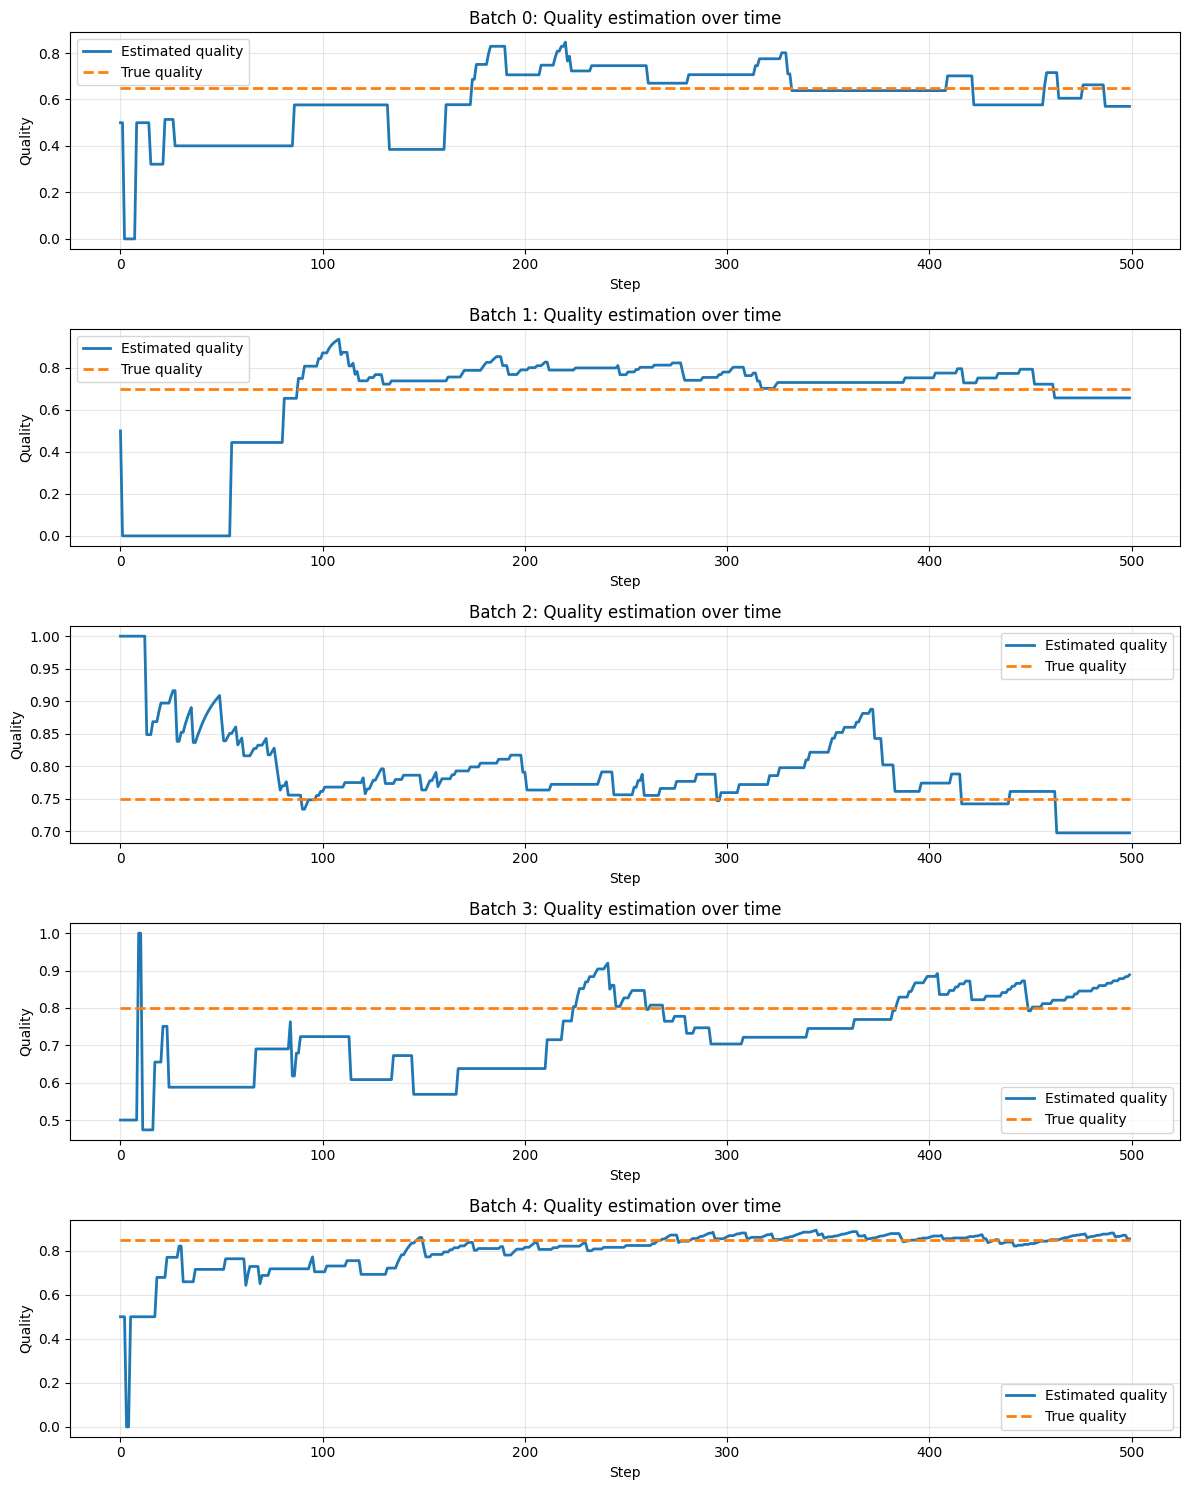

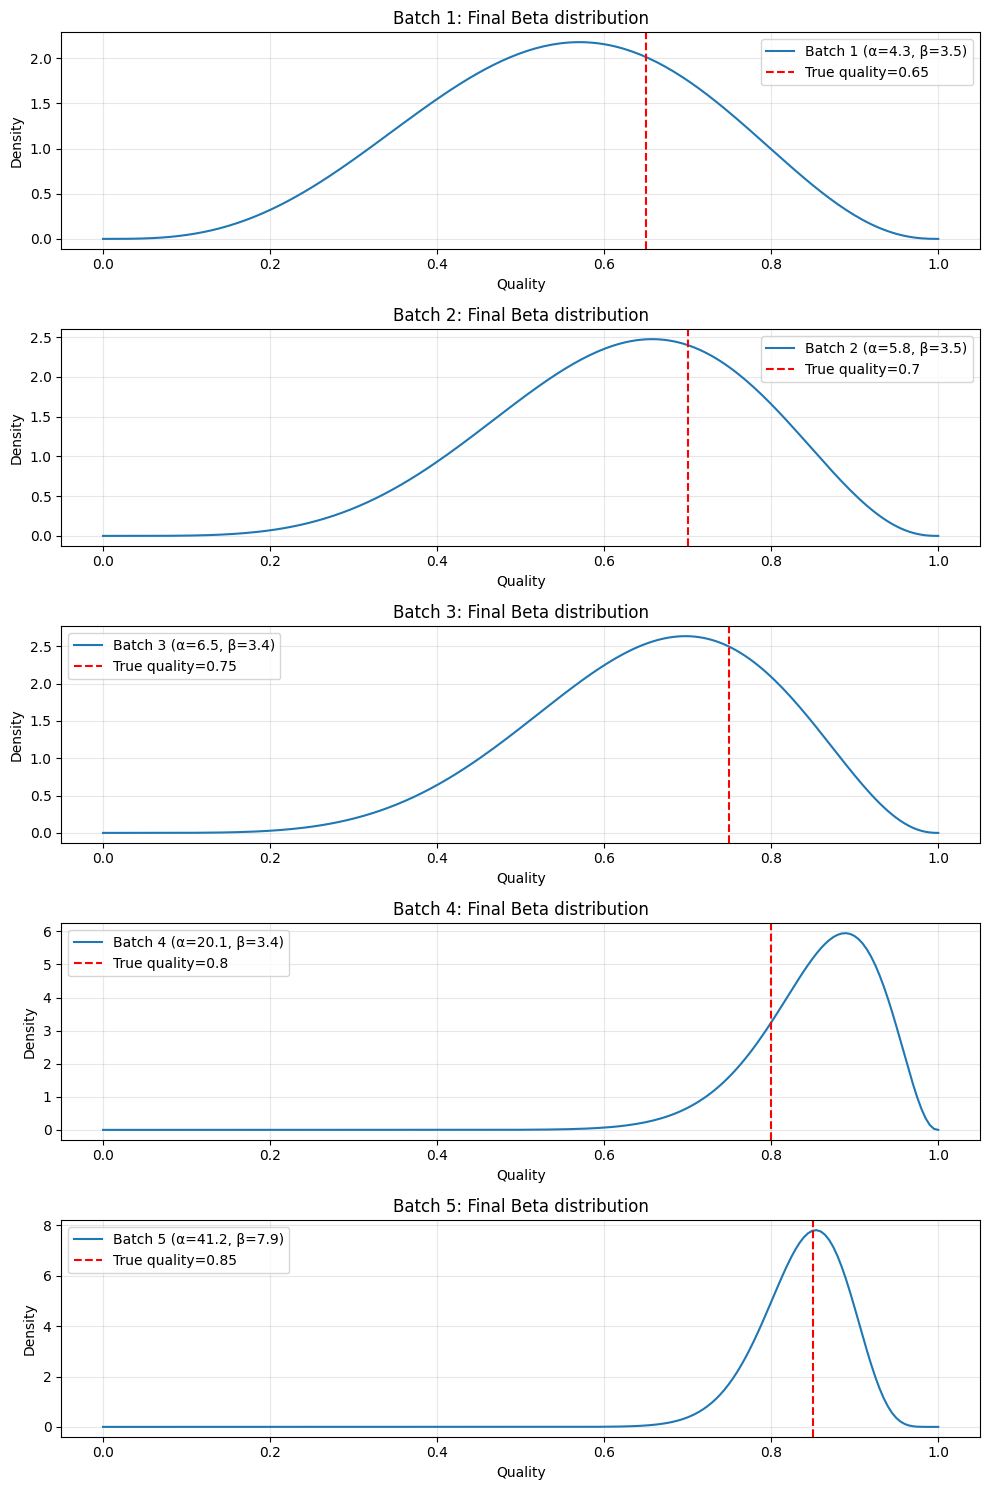

In [288]:
# Plot the evolution of Beta distributions over time for each batch
fig, axes = plt.subplots(len(init_qualities), 1, figsize=(12, 3*len(init_qualities)))

if len(init_qualities) == 1:
    axes = [axes]

for i in range(len(init_qualities)):
    # Extract history for this batch
    alphas = np.array(history[i]['alpha'])
    betas = np.array(history[i]['beta'])
    qualities = np.array(history[i]['quality'])
    
    # Plot mean estimate over time
    means = (alphas - 1) / (alphas + betas - 2)
    means = np.where((alphas + betas - 2) > 0, means, 0.5)
    
    axes[i].plot(range(STEPS), means, label=f'Estimated quality', linewidth=2)
    axes[i].plot(range(STEPS), qualities, label='True quality', linestyle='--', linewidth=2)
    axes[i].set_xlabel('Step')
    axes[i].set_ylabel('Quality')
    axes[i].set_title(f'Batch {i}: Quality estimation over time')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot final Beta distributions
x_dist = np.linspace(0, 1, 200)
fig2, axes2 = plt.subplots(len(init_qualities), 1, figsize=(10, 3*len(init_qualities)))

if len(init_qualities) == 1:
    axes2 = [axes2]

for i in range(len(init_qualities)):
    alpha_final = factory.batches[i].alpha
    beta_final = factory.batches[i].beta
    true_quality = factory.batches[i].quality
    
    y_dist = beta.pdf(x_dist, alpha_final, beta_final)
    axes2[i].plot(x_dist, y_dist, label=f'Batch {i+1} (α={alpha_final:.1f}, β={beta_final:.1f})')
    axes2[i].axvline(true_quality, color='r', linestyle='--', label=f'True quality={true_quality}')
    axes2[i].set_title(f'Batch {i+1}: Final Beta distribution')
    axes2[i].legend()
    axes2[i].set_xlabel('Quality')
    axes2[i].set_ylabel('Density')
    axes2[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()